Djedjik Samir     -                              PT   -                                Informatique commune

# Base de données (BDD) - TP3

**Objectifs du TP3:** 
Dans les 2 TP précédents, vous avez vu l'essentiel des éléments formant le socle des requêtes utilisées dans le domaine des bases de données. Dans ce dernier TP, vous allez découvrir les principales clauses permettant de classer les résultats d'une requête, la réorganisation des données d'une table, utiliser des requêtes comportant des prédicats, ...
Le sommaire est le suivant:
1.  Les fonctions d'agrégation 
2. La clause GROUP BY
3. La clause HAVING
4. La clause ORDER
5. Quelques requêtes à écrire

Nous gardons la même base de données cinémas que nous avons utilisés dans les TP 1 et 2. Rappelons le schéma relationnel:

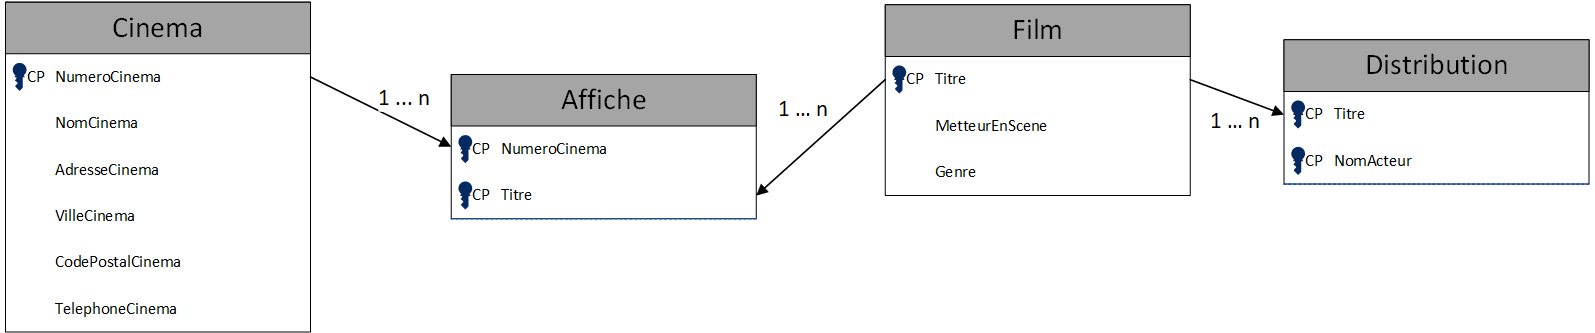

In [15]:
# Chargement de la bibliothèque sql permettant d'utiliser des requêtes du langage SQL dans ce notebook Jupyter
%load_ext sql

%config SqlMagic.style = '_DEPRECATED_DEFAULT'

# Chargement de la base de données "cinemas"
%sql sqlite:///cinemas.db

# Si une erreur de type "KeyError: 'DEFAULT'" apparaît alors elle ne vient pas de SQLite ni de votre requête SQL mais du package 
# ipython-sql / prettytable qui essaie d’utiliser un style nommé "DEFAULT"… qui n’existe plus dans certaines versions récentes de prettytable.
# la solution consiste à précéder votre requête de la ligne en commentaire au dessus de la requête



# 1. Les fonctions d'agrégation

Les fonctions de groupe ou fonctions d'agrégation permettent d'obtenir des informations sur un ensemble de t-uplets dans une table. On a les fonctions suivantes:
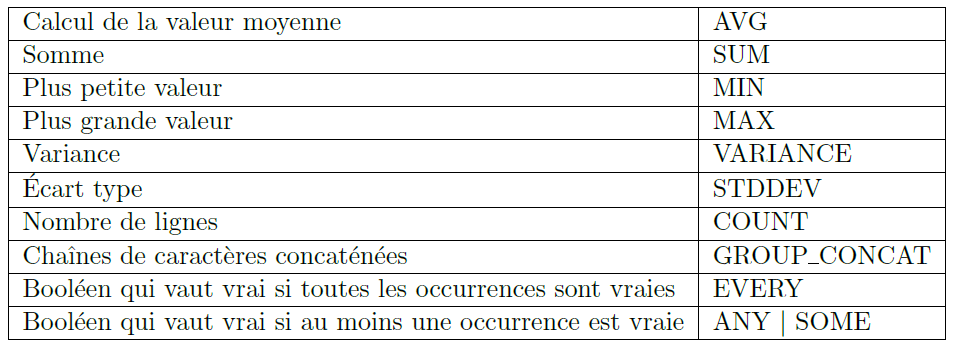

Lorsque l'on utilise une telle fonction, on travaille sur une colonne et non pas sur une ligne (tuplet) comme dans une clause WHERE.

On peut de plus utiliser les mots réservés ALL ou DISTINCT pour les fonctions statistiques.

### Exemple:

In [19]:
%sql SELECT * FROM affiche

 * sqlite:///cinemas.db
Done.


NumeroCinema,Titre
1,Alerte
1,Junior
2,Alerte
2,Gazon Maudit
2,L'Effaceur
3,Alerte
3,Casper
4,Alerte
4,Casper
4,Harcelement


Exécuter la requête suivante qui donne le nombre de films à l'affiche du cinéma N°1 et vérifier si le résultat est juste.

In [20]:
%sql SELECT COUNT(Titre) AS NbFilms FROM affiche WHERE NumeroCinema = 1

 * sqlite:///cinemas.db
Done.


NbFilms
2


Pour l'exemple qui va suivre, rappelons le contenu de la relation Cinema 

In [21]:
%sql SELECT * FROM cinema

 * sqlite:///cinemas.db
Done.


NumeroCinema,NomCinema,AdresseCinema,VilleCinema,CodePostalCinema,TelephoneCinema
1,Vox,Grande Rue,Besancon,25000,03 81 82 05 69
2,Plazza,Rue Des Granges,Besancon,25000,03 81 26 35 98
3,Eldorado,Rue St. Lambert,Paris,75015,01 23 56 98 56
4,Pax,Avenue d'Italie,Paris,75013,01 23 56 98 78


La requête suivante donne le plus petit code postal répertorié dans la relation CINEMA. L'exécuter et vérifier la conformité du résultat attendu.

In [22]:
%sql SELECT MIN(CodePostalCinema) AS PlusPetit FROM cinema

 * sqlite:///cinemas.db
Done.


PlusPetit
25000


Réessayer cette même requête à la différence que le résultat n'est pas renommé

In [23]:
%sql SELECT MIN(CodePostalCinema) FROM cinema

 * sqlite:///cinemas.db
Done.


MIN(CodePostalCinema)
25000


Dans les deux requêtes ci-dessous, on a renommé le résultat en utilisant le terme AS. Lorsque l'on utilise des fonctions de groupe, le résultat est nommé automatiquement par le SGBD, ce qui donne des noms du type MIN(CodePostalCinema). Pour obtenir un résultat qui soit en particulier réutilisable, il convient de le renommer.

**Q1. Exécuter cette dernière requête et expliquer ce que réalise la fonction GROUP_CONCAT de manière générale. Décrire ce que cette fonction réalise dans cette requête en particulier.**

In [24]:
%sql SELECT VilleCinema, GROUP_CONCAT(CodePostalCinema) FROM cinema WHERE VilleCinema='Paris'

 * sqlite:///cinemas.db
Done.


VilleCinema,GROUP_CONCAT(CodePostalCinema)
Paris,"75015,75013"


### Particularités de la fonction COUNT

Il existe différentes syntaxes pour utiliser la fonction COUNT.

- COUNT(*) : compte le nombre de t-uplets obtenus dans la requête (lignes).
- COUNT(attribut) : compte le nombre de t-uplets dont la valeur de l'attribut existe
- COUNT(DISTINCT attribut) : compte le nombre de valeurs différentes (ou distinctes) de l'attribut.

Rappelons le contenu de la relation affiche

In [25]:
%sql SELECT * FROM affiche

 * sqlite:///cinemas.db
Done.


NumeroCinema,Titre
1,Alerte
1,Junior
2,Alerte
2,Gazon Maudit
2,L'Effaceur
3,Alerte
3,Casper
4,Alerte
4,Casper
4,Harcelement


**Q2. Décrire les 3 requêtes suivantes**

In [26]:
%sql SELECT count(*) FROM affiche

 * sqlite:///cinemas.db
Done.


count(*)
10


In [27]:
%sql SELECT count(Titre) FROM affiche

 * sqlite:///cinemas.db
Done.


count(Titre)
10


In [30]:
%sql SELECT count(DISTINCT Titre) FROM affiche

 * sqlite:///cinemas.db
Done.


count(DISTINCT Titre)
6


### Exercice sur les fonctions d'agrégation

**Q3. Décrire en SQL les 3 requêtes suivantes :**
- Donner le nombre de films de comédie. Attention, dans votre base de données, les genres de film sont renseignés avec une majuscule et sans accent!

In [31]:
%sql SELECT * FROM FILM

 * sqlite:///cinemas.db
Done.


Titre,MetteurEnScene,Genre
Alerte,Peterson,Aventure
Casper,Silberling,Comedie
Gazon Maudit,Balasko,Comedie
Harcelement,Levinson,Comedie Dramatique
Junior,Reitman,Comedie
L'Effaceur,Russel,Action
Les Voleurs,Techine,Comedie Dramatique
Ma Saison Preferee,Techine,Comedie Dramatique


In [32]:
%sql SELECT count(Genre) FROM film WHERE Genre='Comedie'

 * sqlite:///cinemas.db
Done.


count(Genre)
3


- Donner le plus petit numéro de cinéma dans lequel est à l'affiche le film "Alerte".

In [37]:
%sql SELECT MIN(NumeroCinema) FROM affiche WHERE Titre='Alerte'

 * sqlite:///cinemas.db
Done.


MIN(NumeroCinema)
1


- Donner le nombre de films à l'affiche à Besançon.

In [39]:
%sql SELECT count(affiche.NumeroCinema) FROM cinema JOIN affiche ON cinema.NumeroCinema=affiche.NumeroCinema WHERE VilleCinema='Besancon'

 * sqlite:///cinemas.db
Done.


count(affiche.NumeroCinema)
5


# 2 La clause GROUP BY

## 2.1 Présentation de la clause GROUP BY

La clause GROUP BY permet :
- de subdiviser la table en groupes
- une seule ligne représente l'ensemble des t-uplets de la table regroupés, tous les t-uplets regroupés ont la même valeur pour les expressions du regroupement.


Syntaxe de la clause GROUP BY
GROUP BY expr1, expr2, ...

Rappelons le contenu de la relation AFFICHE 

In [40]:
%sql SELECT * FROM affiche

 * sqlite:///cinemas.db
Done.


NumeroCinema,Titre
1,Alerte
1,Junior
2,Alerte
2,Gazon Maudit
2,L'Effaceur
3,Alerte
3,Casper
4,Alerte
4,Casper
4,Harcelement


Le regroupement de cette table par rapport à l'attribut NumeroCinema s'écrit en SQL comme suit et donne le résultat affiché suivant:

SELECT ... FROM affiche GROUP BY NumeroCinema
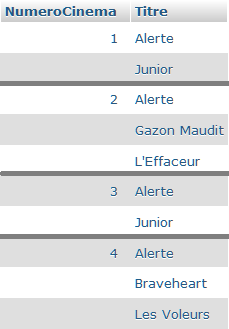

Le regroupement est réalisé ici par rapport à l'attribut NumeroCinema. 

On retrouve dans chaque ligne du regroupement tous les éléments correspondant à une même valeur de l'attribut NumeroCinema. On obtient 4 groupes. 

On peut se rendre compte que cette table n'est pas "correcte", en ce sens que les valeurs de  l'attribut Titre ne sont plus atomiques. A ce titre, les informations que l'on va pouvoir extraire d'une telle table sont limitées. On ne peut pas par exemple donner le titre d'un film pour le premier regroupement.

## 2.2 Les restrictions liées à la clause GROUP BY

Les seules opérations réalisables sur une "table regroupée" sont des opérations qui prennent en compte un ensemble de lignes, comme les fonctions de groupe, ou alors des opérations de projection portant sur des attributs impliqués dans le regroupement.

Dans l'exemple précédent, on peut par exemple :
- appliquer des fonctions de groupe sur l'attribut Titre,
- réaliser une projection sur l'attribut NumeroCinema.

La requête suivante permet de compter pour chaque cinéma le nombre de films qui y sont à l'affiche:

In [42]:
%sql SELECT NumeroCinema, COUNT(Titre) AS NBFilms FROM affiche GROUP BY NumeroCinema

 * sqlite:///cinemas.db
Done.


NumeroCinema,NBFilms
1,2
2,3
3,2
4,3


Vous pouvez vous rendre compte de la différence du résultat avec la requête précédente sans la clause GROUP BY:

In [43]:
%sql SELECT NumeroCinema, COUNT(Titre) AS NBFilms FROM affiche

 * sqlite:///cinemas.db
Done.


NumeroCinema,NBFilms
1,10


## 2.3 Entrainez-vous!

**Q4. Décrire en SQL les requêtes suivantes et présenter à chaque fois sur une feuille la table intermédiaire définie par le regroupement :**

- Donner pour chaque acteur le nombre de films dans lesquels il joue.

In [48]:
%sql SELECT NomActeur, COUNT(Titre) FROM distribution GROUP BY NomActeur

 * sqlite:///cinemas.db
Done.


NomActeur,COUNT(Titre)
Abril,1
Balasko,1
Chabat,1
De Mornay,1
De Niro,1
Douglas,1
Freeman,1
Hoffman,1
Moore,1
Pullman,1


- Donner pour chaque film, le premier acteur par ordre alphabétique (la fonction MIN s'applique pour les lettres alphabétiques).

In [49]:
%sql SELECT MIN(NomActeur),Titre FROM distribution GROUP BY Titre 

 * sqlite:///cinemas.db
Done.


MIN(NomActeur),Titre
Freeman,Alerte
Pullman,Casper
Abril,Gazon Maudit
Douglas,Harcelement
De Mornay,Junior
Schwarzenegger,L'Effaceur


- Donner pour chaque cinéma, le nombre de films à l'affiche. On donnera le nom du cinéma et le nombre de titres à l'affiche dans celui-ci.

In [78]:
%sql SELECT NomCinema,COUNT(Titre) FROM cinema JOIN affiche ON affiche.NumeroCinema=cinema.NumeroCinema GROUP BY NomCinema

 * sqlite:///cinemas.db
Done.


NomCinema,COUNT(Titre)
Eldorado,2
Pax,3
Plazza,3
Vox,2


# 3 La clause HAVING

La clause HAVING permet de sélectionner des groupes définis par la clause GROUP BY.

Syntaxe de la clause HAVING: HAVING prédicat

Le prédicat associé à une clause HAVING est défini de la même façon que les prédicats de la clause WHERE, mais il ne peut porter que sur les groupes défnis par la clause GROUP BY.

Reprenons l'exemple vu dans la présentation de la clause GROUP BY, qui permet de compter pour chaque cinéma, le nombre de films qui y sont à l'affiche. Et supposons qu'ici nous voulions sélectionner le numéro de cinémas dans lesquels il y a au moins trois films à l'affiche. 

En SQL, cette requête est traduite par :

In [61]:
%sql SELECT NumeroCinema FROM affiche GROUP BY NumeroCinema HAVING COUNT(titre) > 2

 * sqlite:///cinemas.db
Done.


NumeroCinema
2
4


Cette condition ne peut pas être exprimée dans une clause WHERE, car comme nous l'avons dit dans la présentation d'une requête SELECT, la clause WHERE est évaluée **avant le regroupement**.

Reprenons la requête que nous venons de présenter et regardons comment elle est évaluée. 
Lors de l'évaluation d'une requête, la première clause traitée est la clause WHERE, ici il n'y en a pas.
Ensuite, on évalue la clause GROUP BY, ce qui donne la table intermédiaire suivante:

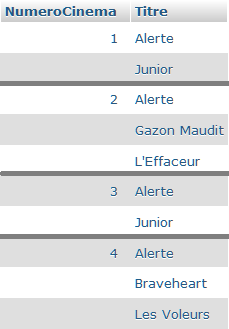

Puis, on évalue les fonctions d'agrégation comme suit:
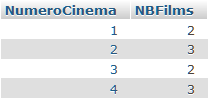

et enfin, la clause HAVING est appliquée:
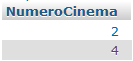

**Q5. Décrire en SQL les requêtes suivantes :**
- Donner le nom des acteurs qui jouent dans au moins deux films.

In [63]:
%sql SELECT NomActeur FROM distribution GROUP BY NomActeur HAVING COUNT(Titre)>1

 * sqlite:///cinemas.db
Done.


NomActeur
Schwarzenegger


- Donner les titres des films qui ont au plus deux acteurs dans leur distribution.

In [64]:
%sql SELECT Titre FROM distribution GROUP BY Titre HAVING COUNT(NomActeur)<3 

 * sqlite:///cinemas.db
Done.


Titre
Casper
Harcelement
L'Effaceur


# 4. La clause ORDER

La clause ORDER permet de préciser dans quel ordre les t-uplets sélectionnés seront donnés. Le tri peut s'effectuer selon plusieurs critères, en allant du premier au dernier.

Syntaxe de la clause ORDER:    ORDER BY Expr1 [DESC], Expr2 [DESC], ...

Cette clause ne modifie pas l'ensemble des données retournées par la requête, mais simplement leur ordre de présentation. Les expressions sont généralement des noms d'attributs. On peut trier par ordre croissant par défaut, ou par ordre décroissant, en utilisant dans ce cas le mot réservé DESC.

Par exemple, pour donner la liste des noms de cinémas par ordre alphabétique, on a la requête :

In [65]:
%sql SELECT NomCinema, VilleCinema FROM cinema ORDER BY NomCinema

 * sqlite:///cinemas.db
Done.


NomCinema,VilleCinema
Eldorado,Paris
Pax,Paris
Plazza,Besancon
Vox,Besancon


Et la requête ci-dessous donne le nom et la ville des cinémas, en respectant l'ordre alphabétique des villes, puis des cinémas.

In [66]:
%sql SELECT NomCinema, VilleCinema FROM cinema ORDER BY VilleCinema, NomCinema

 * sqlite:///cinemas.db
Done.


NomCinema,VilleCinema
Plazza,Besancon
Vox,Besancon
Eldorado,Paris
Pax,Paris


**Q6. Décrire en SQL les requêtes suivantes, et présenter à chaque fois la table obtenue :**

- Donner pour chaque acteur le nombre de films dans lesquels il joue, la liste sera triée par ordre décroissant du nombre de films.

In [69]:
%sql SELECT NomActeur,COUNT(Titre) AS n FROM distribution GROUP BY NomActeur ORDER BY n DESC

 * sqlite:///cinemas.db
Done.


NomActeur,n
Schwarzenegger,2
Russo,1
Ricci,1
Pullman,1
Moore,1
Hoffman,1
Freeman,1
Douglas,1
De Niro,1
De Mornay,1


- Afficher les informations concernant les films en les triant par genre, et par titre.

In [71]:
%sql SELECT Genre,Titre FROM film ORDER BY Genre

 * sqlite:///cinemas.db
Done.


Genre,Titre
Action,L'Effaceur
Aventure,Alerte
Comedie,Casper
Comedie,Gazon Maudit
Comedie,Junior
Comedie Dramatique,Harcelement
Comedie Dramatique,Les Voleurs
Comedie Dramatique,Ma Saison Preferee


# 5. Requêtes à écrire!

On se propose dans cette partie de reprendre toutes les compétences acquises depuis le TP1 en écrivant en SQL les requêtes qui vont suivre. 

La base de données est toujours celle étudiée depuis le début, à savoir cinémas.

On rappelle le modèle relationnel de cette base de données:
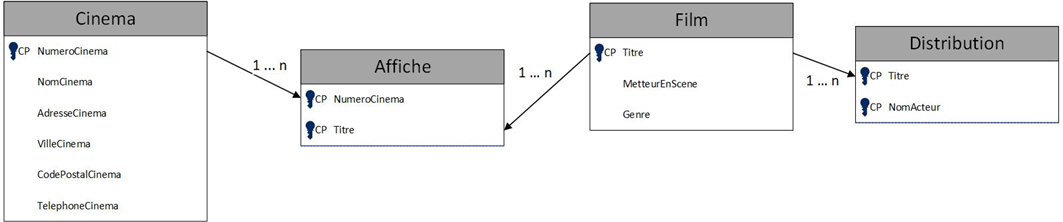

## 5.1 Quelques requêtes plus ou moins simples

**a. Donner le nom des cinémas de cette base de données**

In [72]:
%sql SELECT NomCinema FROM cinema

 * sqlite:///cinemas.db
Done.


NomCinema
Vox
Plazza
Eldorado
Pax


**b. Le nom et l'adresse et numéro de téléphone des cinémas projetant le film "Junior"**

In [74]:
%sql SELECT NomCinema, AdresseCinema, TelephoneCinema FROM cinema JOIN affiche on cinema.NumeroCinema=affiche.NumeroCinema WHERE Titre='Junior'

 * sqlite:///cinemas.db
Done.


NomCinema,AdresseCinema,TelephoneCinema
Vox,Grande Rue,03 81 82 05 69


**c. Le nom des metteurs en scène des films à l'affiche du PAX**

In [81]:
%sql SELECT MetteurEnScene FROM cinema JOIN affiche ON cinema.NumeroCinema=affiche.NumeroCinema JOIN film ON affiche.titre=film.Titre WHERE NomCinema='Pax'

 * sqlite:///cinemas.db
Done.


MetteurEnScene
Peterson
Silberling
Levinson


**d. Le nom des acteurs apparaissant dans la distribution des films à l'affiche à Besançon.**

In [83]:
%sql SELECT DISTINCT NomActeur FROM cinema JOIN affiche ON cinema.NumeroCinema=affiche.NumeroCinema JOIN distribution ON affiche.titre=distribution.Titre WHERE VilleCinema='Besancon'

 * sqlite:///cinemas.db
Done.


NomActeur
Freeman
Hoffman
Russo
De Mornay
De Niro
Schwarzenegger
Abril
Balasko
Chabat


**e. Le titre des films avec Schwarzenegger à l'affiche à Besançon.**

**f. Le titre des films d'aventure à l'affiche à Besançon, et le nom du cinéma où ils sont à l'affiche.**

**g. Le titre des films ayant le même metteur en scène que "les voleurs"**

## 5.2 Quelques requêtes moins évidentes ...

**h. Le nom des cinémas de Paris ayant à l'affiche une comédie et une comédie
dramatique.**

**i. Le nombre de Cinémas à Besancon**

**j. Pour chaque cinéma, donnez le nombre de films à l'affiche.**

**k. Le nom des cinémas ainsi que le nombre de films à l'affiche dans ceux-ci**

**l. Le numéro des cinémas ayant au moins deux films à l'affiche**

**m. Le nom des cinémas ayant au moins deux films à l'affiche**

**n. Le titre des films n'ayant pas Schwarzenegger dans leur distribution**